In [1]:
import os
import torch
import pandas as pd
from epiweeks import Week
import preprocess_data as prep
import model as mc
import matplotlib.pyplot as plt 

pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

columns_to_normalize = ['casos','epiweek', 'biome', 'enso']

predict_n = 30
max_epiweek = 22
    
boxcox = False
min_year = 2015

TEST_YEAR = 2026
media = False

In [2]:
doenca = 'dengue'
model_name = 'enso_22_26_adap_64'
base_model = 'base_22_26'
enso_model = 'enso_22_26'
filename = f'./data/{doenca}.csv.gz'

df = prep.load_cases_data(filename)

df = df.loc[df.epiweek <= int(f'{TEST_YEAR}{max_epiweek}')]

enso = prep.load_enso_weekly(filename='data/enso_weekly_forecast_up_25_07.csv')

enso_neutro = prep.load_enso_weekly(filename='data/enso_weekly_neutro_up_25_07.csv')

#enso = None 
#enso_neutro = None


In [7]:
import numpy as np

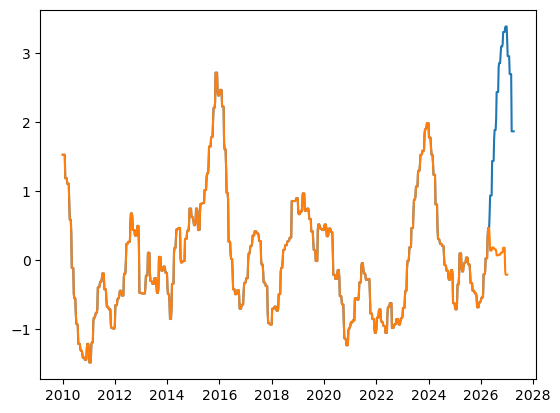

In [9]:
_,ax = plt.subplots()

ax.plot(enso['enso'])
ax.plot(enso_neutro['enso'])

Run for state: 

In [ ]:
for region in regioes_estados.keys(): 

    print(region)

    label = f'{region}_{TEST_YEAR-1}_{model_name}'

    for state in regioes_estados[region]: 

        df_reg = df.loc[df.uf ==state]
        df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]
        

        model = mc.load_model(
                        region,
                        TEST_YEAR,
                        doenca,
                        model_name,
                        predict_n,
                        max_epiweek,
                        device,
                        base_model,
                        enso_model
                    )  

        filename_el_nino = f'predictions/preds_{doenca}_{state}_{TEST_YEAR}_{model_name}.csv'

        if os.path.exists(filename_el_nino):
            df_preds = pd.read_csv(filename_el_nino)
            df_preds.date = pd.to_datetime(df_preds.date)
        else:
            df_preds =  mc.sum_regions_predictions(model, df_reg, enso, TEST_YEAR, columns_to_normalize,
                                            max_epiweek = max_epiweek,
                                            boxcox = boxcox,
                                            n_passes = 500,
                                            min_year= min_year, media = media)

                
            df_preds.to_csv(filename_el_nino)

        if enso_neutro is not None: 
            filename_neutro = f'predictions/preds_{doenca}_{state}_{TEST_YEAR}_neutro_{model_name}.csv'

            if os.path.exists(filename_neutro):
                df_preds_neutro = pd.read_csv(filename_neutro)
                df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)
            else:

                df_preds_neutro =  mc.sum_regions_predictions(model, df_reg, enso_neutro, TEST_YEAR, columns_to_normalize,
                                                max_epiweek = max_epiweek,
                                                boxcox = boxcox,
                                                n_passes = 500,
                                                min_year= min_year, media = media)

                    
                df_preds_neutro.to_csv(filename_neutro)


Sul
Sudeste
Nordeste
Centro-Oeste
Norte


Run for region: 

In [3]:
for region in ['Sudeste']: 

    print(region)

    label = f'{region}_{TEST_YEAR-1}_{model_name}'

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]
    
    if 'dengue' in model_name: 

        model_name_n = model_name[7:]

        model = mc.load_model(
                    region,
                    TEST_YEAR,
                    'dengue',
                    model_name_n,
                    predict_n,
                    max_epiweek,
                    device,
                    base_model,
                    enso_model
                )

    else: 
        model = mc.load_model(
                    region,
                    TEST_YEAR,
                    doenca,
                    model_name,
                    predict_n,
                    max_epiweek,
                    device,
                    base_model,
                    enso_model
                )  
            
    

    filename_el_nino = f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv'

    if os.path.exists(filename_el_nino):
        df_preds = pd.read_csv(filename_el_nino)
        df_preds.date = pd.to_datetime(df_preds.date)
    else:
        df_preds =  mc.sum_regions_predictions(model, df_reg, enso, TEST_YEAR, columns_to_normalize,
                                        max_epiweek = max_epiweek,
                                        boxcox = boxcox,
                                        n_passes = 500,
                                        min_year= min_year, media = media)

            
        df_preds.to_csv(filename_el_nino)

    if enso_neutro is not None: 
        filename_neutro = f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_neutro_{model_name}.csv'

        if os.path.exists(filename_neutro):
            df_preds_neutro = pd.read_csv(filename_neutro)
            df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)
        else:

            df_preds_neutro =  mc.sum_regions_predictions(model, df_reg, enso_neutro, TEST_YEAR, columns_to_normalize,
                                            max_epiweek = max_epiweek,
                                            boxcox = boxcox,
                                            n_passes = 500,
                                           min_year= min_year, media = media)

                
            df_preds_neutro.to_csv(filename_neutro)


Sudeste


### Total cases

In [ ]:
df_end = pd.DataFrame()
for region in regioes_estados.keys(): 

    print(region)

    label = f'{region}_{TEST_YEAR-1}_{model_name}'

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]


    if 'dengue' in model_name: 

        model_name_n = model_name[7:]

        model = mc.load_model(
                    region,
                    TEST_YEAR,
                    'dengue',
                    model_name_n,
                    predict_n,
                    max_epiweek,
                    device,
                    base_model,
                    enso_model
                )

    else: 
        model = mc.load_model(
                    region,
                    TEST_YEAR,
                    doenca,
                    model_name,
                    predict_n,
                    max_epiweek,
                    device,
                    base_model,
                    enso_model
                )  
            
    
    preds =  mc.sum_regions_predictions(model, df_reg, enso, TEST_YEAR, columns_to_normalize,
                                    max_epiweek = max_epiweek,
                                    boxcox = boxcox,
                                    n_passes = 500,
                                    min_year= min_year, media = media, return_samples= True)
    

    df_sum_el_nino = mc.get_total_cases(preds, region, model_name= 'El niño')

    if enso_neutro is not None: 

        preds_neutro =  mc.sum_regions_predictions(model, df_reg, enso_neutro, TEST_YEAR, columns_to_normalize,
                                        max_epiweek = max_epiweek,
                                        boxcox = boxcox,
                                        n_passes = 500,
                                        min_year= min_year, media = media, return_samples=True)
        
        df_sum_neutro = mc.get_total_cases(preds_neutro, region, model_name= 'Neutro')

        
        df_end = pd.concat([df_end, df_sum_el_nino, df_sum_neutro], ignore_index= True)
    else: 
        df_end = pd.concat([df_end, df_sum_el_nino], ignore_index= True)


df_end.to_csv(f'predictions/total_cases_all_regions_{doenca}_{model_name}.csv', index = False)

Sul
Sudeste
Nordeste
Centro-Oeste
Norte


Total cases state: 

In [ ]:
df_end = pd.DataFrame()
for region in ['Sul', 'Sudeste']: 

    print(region)

    label = f'{region}_{TEST_YEAR-1}_{model_name}'


    for state in regioes_estados[region]: 

        df_reg = df.loc[df.uf ==state]
        df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    
        if 'dengue' in model_name: 

            model_name_n = model_name[7:]

            model = mc.load_model(
                        region,
                        TEST_YEAR,
                        'dengue',
                        model_name_n,
                        predict_n,
                        max_epiweek,
                        device,
                        base_model,
                        enso_model
                    )

        else: 
            model = mc.load_model(
                        region,
                        TEST_YEAR,
                        doenca,
                        model_name,
                        predict_n,
                        max_epiweek,
                        device,
                        base_model,
                        enso_model
                    )  
                
        
        preds =  mc.sum_regions_predictions(model, df_reg, enso, TEST_YEAR, columns_to_normalize,
                                        max_epiweek = max_epiweek,
                                        boxcox = boxcox,
                                        n_passes = 500,
                                        min_year= min_year, media = media, return_samples= True)
        

        df_sum_el_nino = mc.get_total_cases(preds, state, model_name= 'El niño')

        if enso_neutro is not None: 

            preds_neutro =  mc.sum_regions_predictions(model, df_reg, enso_neutro, TEST_YEAR, columns_to_normalize,
                                            max_epiweek = max_epiweek,
                                            boxcox = boxcox,
                                            n_passes = 500,
                                            min_year= min_year, media = media, return_samples=True)
            
            df_sum_neutro = mc.get_total_cases(preds_neutro, state, model_name= 'Neutro')

            
            df_end = pd.concat([df_end, df_sum_el_nino, df_sum_neutro], ignore_index= True)
        else: 
            df_end = pd.concat([df_end, df_sum_el_nino], ignore_index= True)


df_end.to_csv(f'predictions/total_cases_all_regions_state_{doenca}_{model_name}.csv', index = False)

Sul
Sudeste


In [4]:
df_end

,regional_geocode,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95,model
0,Sul,3133.624652,2579.336853,3838.348839,2132.045269,4758.134577,1939.827255,5603.497359,1812.858865,6398.044620,El niño
1,Sul,2322.728980,1897.783445,2816.697991,1622.072643,3411.810574,1421.659350,3791.505928,1279.804895,4354.764200,Neutro
2,Sul,5822.718966,5137.716502,6841.778061,4656.550226,8010.249214,4289.002899,8869.507386,3942.548896,10142.657715,El niño
3,Sul,4419.967378,3804.757291,5095.895646,3396.342534,6069.196682,3198.494627,6841.655407,2998.509441,7565.707689,Neutro
4,Sul,2893.373871,2435.387138,3414.443212,2112.435470,4111.889327,1967.365349,4697.540466,1759.463581,5275.082305,El niño
5,Sul,2220.160969,1893.032010,2628.793997,1651.749178,3169.323516,1525.686889,3516.226660,1413.075477,4218.764187,Neutro
6,Sudeste,55483.797720,50559.212122,62283.919466,47019.278882,69163.882434,45584.526022,75271.211105,44145.561827,79817.346126,El niño
7,Sudeste,29884.724711,27910.799519,31930.950755,26500.332200,34388.071696,25779.178014,36714.920746,24971.451246,38242.420525,Neutro
8,Sudeste,48063.313392,45115.032044,51879.015476,42589.828372,56308.370244,41241.972782,58645.352027,40207.158780,64032.681831,El niño
9,Sudeste,26431.108277,25122.995117,28164.833733,24010.813654,30086.878124,23352.573968,31847.464733,22993.704963,33213.832117,Neutro
